In [49]:
%load_ext autoreload
%autoreload 2

import os,sys
parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
import util as yu
from util import *
import util_Nsgm as yu2

yu.setpath('analysis_3ptGEVP_laplace')

ens='b'
tfs=[8,10,12,14,16,18,20]

yunit_mul=yu.ens2amul_iso[ens]*yu.ens2aInv[ens]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [50]:
[c2ptM,tf2c3ptM,c2ptCorrDic_NJN]=yu.load_pkl_reg('data',pathlabel='processData')
tf2c3ptM={tf:np.real(tf2c3ptM[tf]) for tf in tf2c3ptM.keys()}

t=yu.load_pkl_reg('ens2pars_jk_meffnst_selected',pathlabel='analysis_2pt')
[pars_jk_meff1st,pars_jk_meff2st,pars_jk_meff3st]=[t[0][ens],t[1][ens],t[2][ens]]
[v_selected,w_selected]=yu.load_pkl_reg('vw',pathlabel='analysis_2ptGEVP')

In [51]:
tf2ratio_noGEVP={tf:tf2c3ptM[tf][:,:,0,0]/c2ptCorrDic_NJN[tf][:,None] for tf in tfs}
tf2ratio_GEVP={}
for tf in tfs:
    t=[ (c3ptM[:,0,0]*(1-w**2) + v*(1+w)*(c3ptM[:,0,1]+c3ptM[:,1,0]) ) /  \
        (c2pt + v*(c2ptM[tf,0,1]+c2ptM[tf,1,0]) + v**2*c2ptM[tf,1,1] )[None]    \
        for c3ptM,c2ptM,c2pt,v,w in zip(tf2c3ptM[tf],c2ptM,c2ptCorrDic_NJN[tf],v_selected,w_selected)]
    tf2ratio_GEVP[tf]=np.array(t)

In [52]:
dic={'tf2ratio':tf2ratio_noGEVP, 'mfc:[global]':['white'], 'shift:[rainbow,midpoint,fit]':[0.2,0.2,0], 'xyunit':(yu.ens2a[ens],yunit_mul) }
fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','midpoint'])
axs[0,0].set_ylim([0,80])
dic={'tf2ratio':tf2ratio_GEVP, 'mfc:[global]':['None'], 'xyunit':(yu.ens2a[ens],yunit_mul) }
fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','midpoint'],figAxs=(fig,axs))
fig.suptitle('open (R_std); filled (R_GEVP)')
yu.finalizePlot('Rstd_RGEVP')

In [53]:
n=2
def dE2tf2ratio(dE):
    lbd0=dE*n
    lbd=np.sqrt(np.exp(-lbd0)+np.exp(lbd0)-2)
    
    tf2ratio={}
    for tf in tfs:
        c2=np.array([c2ptM[tf,0,0]   for c3ptM,c2ptM,c2pt,v,w in zip(tf2c3ptM[tf],c2ptM,c2ptCorrDic_NJN[tf],v_selected,w_selected)])
        c3=np.array([c3ptM[:,0,0] for c3ptM,c2ptM,c2pt,v,w in zip(tf2c3ptM[tf],c2ptM,c2ptCorrDic_NJN[tf],v_selected,w_selected)])
        
        c3pt=-(np.roll(c3,-n,axis=-1)+np.roll(c3,n,axis=-1)-2*c3) + lbd[:,None]**2*c3
        c2pt=(lbd**2)*c2
        
        ratio=c3pt/c2pt[:,None]
        tf2ratio[tf]=ratio
    return tf2ratio

def dE2tf2ratio_GEVP(dE):
    lbd0=dE*n
    lbd=np.sqrt(np.exp(-lbd0)+np.exp(lbd0)-2)
    
    tf2ratio={}
    for tf in tfs:
        c2=np.array([c2pt + v*(c2ptM[tf,0,1]+c2ptM[tf,1,0]) + v**2*c2ptM[tf,1,1]  for c3ptM,c2ptM,c2pt,v,w in zip(tf2c3ptM[tf],c2ptM,c2ptCorrDic_NJN[tf],v_selected,w_selected)])
        c3=np.array([c3ptM[:,0,0]*(1-w**2) + v*(1+w)*(c3ptM[:,0,1]+c3ptM[:,1,0])  for c3ptM,c2ptM,c2pt,v,w in zip(tf2c3ptM[tf],c2ptM,c2ptCorrDic_NJN[tf],v_selected,w_selected)])
        
        c3pt=-(np.roll(c3,-n,axis=-1)+np.roll(c3,n,axis=-1)-2*c3) + lbd[:,None]**2*c3
        c2pt=(lbd**2)*c2
        
        ratio=c3pt/c2pt[:,None]
        tf2ratio[tf]=ratio
    return tf2ratio

def dEdE2tf2ratio_GEVP(dE1,dE2,n1=n,n2=n):
    lbd0=dE1*n1; lbd1=np.sqrt(np.exp(-lbd0)+np.exp(lbd0)-2)
    lbd0=dE2*n2; lbd2=np.sqrt(np.exp(-lbd0)+np.exp(lbd0)-2)
    
    tf2ratio={}
    for tf in tfs:
        c2=np.array([c2pt + v*(c2ptM[tf,0,1]+c2ptM[tf,1,0]) + v**2*c2ptM[tf,1,1]  for c3ptM,c2ptM,c2pt,v,w in zip(tf2c3ptM[tf],c2ptM,c2ptCorrDic_NJN[tf],v_selected,w_selected)])
        c3=np.array([c3ptM[:,0,0]*(1-w**2) + v*(1+w)*(c3ptM[:,0,1]+c3ptM[:,1,0])  for c3ptM,c2ptM,c2pt,v,w in zip(tf2c3ptM[tf],c2ptM,c2ptCorrDic_NJN[tf],v_selected,w_selected)])
        
        c3=-(np.roll(c3,-n1,axis=-1)+np.roll(c3,n1,axis=-1)-2*c3) + lbd1[:,None]**2*c3
        c3pt=-(np.roll(c3,-n2,axis=-1)+np.roll(c3,n2,axis=-1)-2*c3) + lbd2[:,None]**2*c3
        
        c2pt=(lbd1**2)*(lbd2**2)*c2
        
        ratio=c3pt/c2pt[:,None]
        tf2ratio[tf]=ratio
    return tf2ratio

In [54]:
fits=yu.getFits(f'gS+_{ens}_lbd_True',pathlabel='analysis_3pt_laplace')
fit=[fit for fit in fits if fit[0]==(8,4)][0]
dE=fit[1][:,1]
print(yu.jackme_un2str(fit[1][:,0]*yunit_mul),yu.jackme_un2str(dE*yu.ens2aInv[ens]))

# tf2ratio_laplace_0err=dE2tf2ratio(yu.removeError(dE))
# tf2ratio_laplace=dE2tf2ratio(dE)

48.2(3.1) 364(25)


In [55]:
dic={'tf2ratio':tf2ratio_noGEVP, 'mfc:[global]':['white'], 'shift:[rainbow,midpoint,fit]':[-0.2,-0.2,0], 'xyunit':(yu.ens2a[ens],yunit_mul) }
fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','midpoint'])
axs[0,0].set_ylim([0,80])
dic={'tf2ratio':dE2tf2ratio(dE), 'rainbow:[tfmin,tfmax,tcmin,dt]': [None,None,3,None], 'mfc:[global]':['None'], 'xyunit':(yu.ens2a[ens],yunit_mul) }
fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','midpoint'],figAxs=(fig,axs))
fig.suptitle('open (R_std); filled (R_lap)')
yu.finalizePlot('Rstd_Rlap')

In [56]:
dic={'tf2ratio':tf2ratio_GEVP, 'mfc:[global]':['white'], 'shift:[rainbow,midpoint,fit]':[-0.2,-0.2,0], 'xyunit':(yu.ens2a[ens],yunit_mul) }
fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','midpoint'])
axs[0,0].set_ylim([0,80])
dic={'tf2ratio':dE2tf2ratio_GEVP(dE), 'rainbow:[tfmin,tfmax,tcmin,dt]': [None,None,3,None], 'mfc:[global]':['None'], 'xyunit':(yu.ens2a[ens],yunit_mul) }
fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','midpoint'],figAxs=(fig,axs))
fig.suptitle('open (R_GEVP); filled (R_GEVP_lap)')
yu.finalizePlot('RGEVP_RGEVPlap')

In [57]:
dic={'tf2ratio':dE2tf2ratio(dE), 'rainbow:[tfmin,tfmax,tcmin,dt]': [None,None,3,None], 'mfc:[global]':['white'], 'shift:[rainbow,midpoint,fit]':[-0.2,-0.2,0], 'xyunit':(yu.ens2a[ens],yunit_mul) }
fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','midpoint'])
axs[0,0].set_ylim([0,80])
dic={'tf2ratio':tf2ratio_GEVP, 'rainbow:[tfmin,tfmax,tcmin,dt]': [None,None,3,None], 'mfc:[global]':['None'], 'xyunit':(yu.ens2a[ens],yunit_mul) }
fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','midpoint'],figAxs=(fig,axs))
fig.suptitle('open (R_lap); filled (R_GEVP)')
yu.finalizePlot('Rlap_RGEVP')

In [58]:
dic={'tf2ratio':dE2tf2ratio(dE), 'rainbow:[tfmin,tfmax,tcmin,dt]': [None,None,3,None], 'mfc:[global]':['white'], 'shift:[rainbow,midpoint,fit]':[-0.2,-0.2,0], 'xyunit':(yu.ens2a[ens],yunit_mul) }
fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','midpoint'])
axs[0,0].set_ylim([0,80])
dic={'tf2ratio':dE2tf2ratio_GEVP(dE), 'rainbow:[tfmin,tfmax,tcmin,dt]': [None,None,3,None], 'mfc:[global]':['None'], 'xyunit':(yu.ens2a[ens],yunit_mul) }
fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','midpoint'],figAxs=(fig,axs))
fig.suptitle('open (R_lap); filled (R_GEVP_lap)')
yu.finalizePlot('Rlap_RGEVPlap')

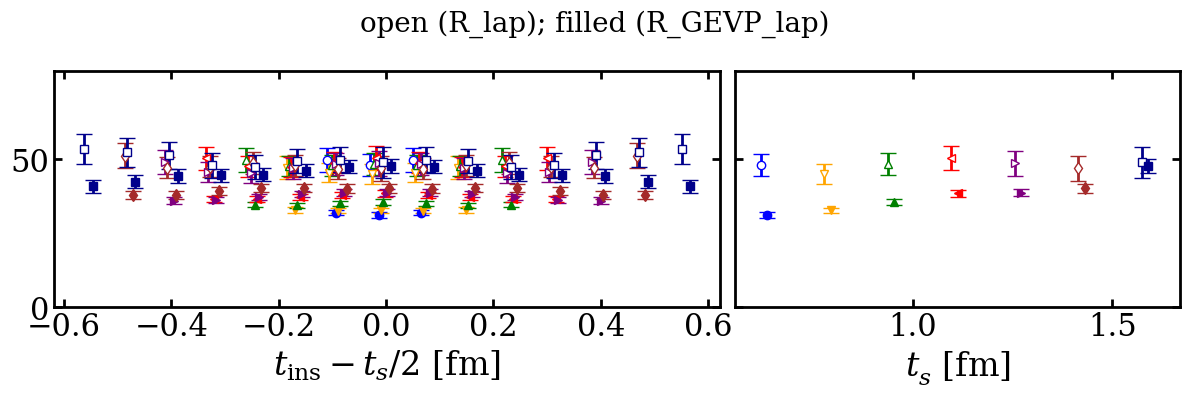

In [59]:
dic={'tf2ratio':dE2tf2ratio(dE), 'rainbow:[tfmin,tfmax,tcmin,dt]': [None,None,3,None], 'mfc:[global]':['white'], 'shift:[rainbow,midpoint,fit]':[-0.2,-0.2,0], 'xyunit':(yu.ens2a[ens],yunit_mul) }
fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','midpoint'])
axs[0,0].set_ylim([0,80])
dic={'tf2ratio':dE2tf2ratio_GEVP(dE*0+800/yu.ens2aInv[ens]), 'rainbow:[tfmin,tfmax,tcmin,dt]': [None,None,3,None], 'mfc:[global]':['None'], 'xyunit':(yu.ens2a[ens],yunit_mul) }
fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','midpoint'],figAxs=(fig,axs))
fig.suptitle('open (R_lap); filled (R_GEVP_lap)')
yu.finalizePlot('Rlap_RGEVPlap',closeQ=False)

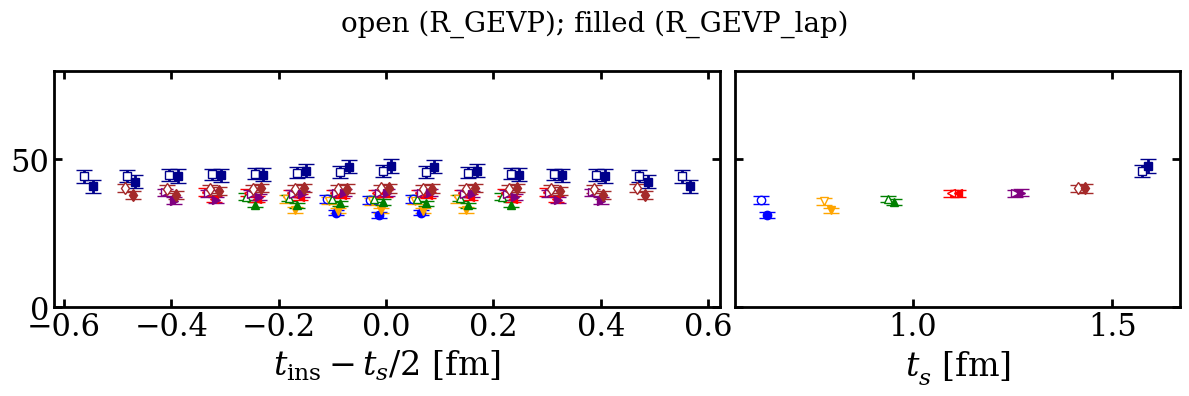

In [60]:
dic={'tf2ratio':tf2ratio_GEVP, 'rainbow:[tfmin,tfmax,tcmin,dt]': [None,None,3,None], 'mfc:[global]':['white'], 'shift:[rainbow,midpoint,fit]':[-0.2,-0.2,0], 'xyunit':(yu.ens2a[ens],yunit_mul) }
fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','midpoint'])
axs[0,0].set_ylim([0,80])
dic={'tf2ratio':dE2tf2ratio_GEVP(dE*0+800/yu.ens2aInv[ens]), 'rainbow:[tfmin,tfmax,tcmin,dt]': [None,None,3,None], 'mfc:[global]':['None'], 'xyunit':(yu.ens2a[ens],yunit_mul) }
fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','midpoint'],figAxs=(fig,axs))
fig.suptitle('open (R_GEVP); filled (R_GEVP_lap)')
yu.finalizePlot(closeQ=False)

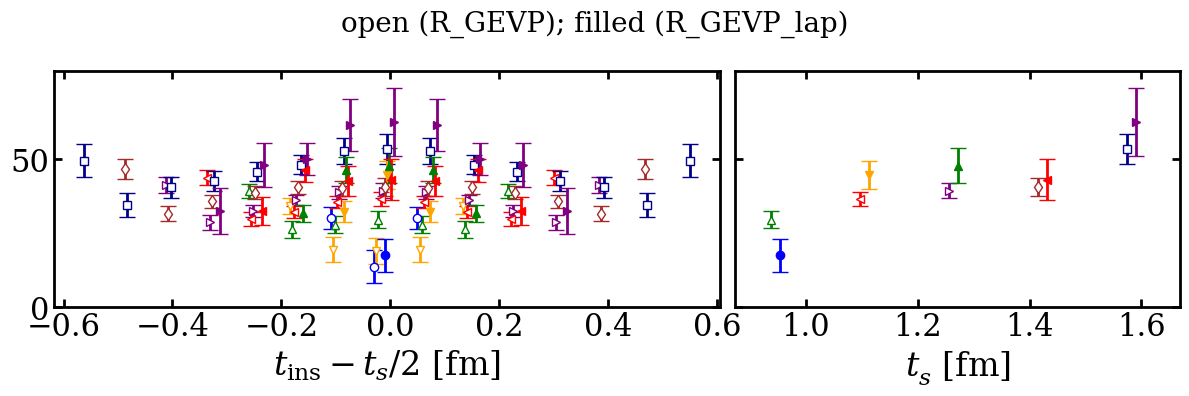

In [209]:
dic={'tf2ratio':dEdE2tf2ratio_GEVP(dE,dE*0+10000/yu.ens2aInv[ens],n1=3,n2=3), 'rainbow:[tfmin,tfmax,tcmin,dt]': [None,None,3,None], 'mfc:[global]':['white'], 'shift:[rainbow,midpoint,fit]':[-0.2,-0.2,0], 'xyunit':(yu.ens2a[ens],yunit_mul) }
fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','midpoint'])
axs[0,0].set_ylim([0,80])
dic={'tf2ratio':dEdE2tf2ratio_GEVP(dE,dE*0+1000/yu.ens2aInv[ens],n1=3,n2=3), 'rainbow:[tfmin,tfmax,tcmin,dt]': [None,None,6,None], 'mfc:[global]':['None'], 'xyunit':(yu.ens2a[ens],yunit_mul) }
fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','midpoint'],figAxs=(fig,axs))
fig.suptitle('open (R_GEVP); filled (R_GEVP_lap)')
yu.finalizePlot(closeQ=False)

In [62]:
# energies
print('mN, dE1, r1, dE2, r2')
print(yu.jackme_un2str(pars_jk_meff2st[:,0]*yu.ens2aInv[ens]),yu.jackme_un2str(pars_jk_meff2st[:,1]*yu.ens2aInv[ens]),yu.jackme_un2str(pars_jk_meff2st[:,2]))
print(yu.jackme_un2str(pars_jk_meff3st[:,0]*yu.ens2aInv[ens]),yu.jackme_un2str(pars_jk_meff3st[:,1]*yu.ens2aInv[ens]),yu.jackme_un2str(pars_jk_meff3st[:,2]),yu.jackme_un2str(pars_jk_meff3st[:,3]*yu.ens2aInv[ens]),yu.jackme_un2str(pars_jk_meff3st[:,4]))

print()

mN=pars_jk_meff2st[:,0]; mpi=140.2/yu.ens2aInv[ens]
p1=2*np.pi/yu.ens2NL[ens]
EN1=np.sqrt(mN**2+p1**2); Epi1=np.sqrt(mpi**2+p1**2); Epi2=np.sqrt(mpi**2+2*p1**2)
print('dE(N0pi0pi0):',(2*mpi)*yu.ens2aInv[ens])
print('dE(N1pi1):',yu.jackme_un2str((EN1+Epi1-mN)*yu.ens2aInv[ens]))
print('dE(N1pi1pi0):',yu.jackme_un2str((EN1+Epi1+mpi-mN)*yu.ens2aInv[ens]))
print('dE(N0pi1pi1):',yu.jackme_un2str((2*Epi1+0.0001*(mN-np.mean(mN)))*yu.ens2aInv[ens]))
print('dE(N0pi2pi2):',yu.jackme_un2str((2*Epi2+0.0001*(mN-np.mean(mN)))*yu.ens2aInv[ens]))

print()

dEs=np.array([280,312,452,531,562,744,811,1000,1400])
print('dE values:',dEs)
print(yu.formatList((-dEs**2+364**2)/(364**2),fmt='.2f'))

mN, dE1, r1, dE2, r2
944.0(4.4) 531(55) 0.803(27)
944.7(5.7) 502(87) 0.710(44) 1740(170) 1.18(10)

dE(N0pi0pi0): 280.4
dE(N1pi1): 312.11(14)
dE(N1pi1pi0): 452.31(14)
dE(N0pi1pi1): 562.31467(44)
dE(N0pi2pi2): 744.15820(44)

dE values: [ 280  312  452  531  562  744  811 1000 1400]
[0.41,0.27,-0.54,-1.13,-1.38,-3.18,-3.96,-6.55,-13.79]


# test

In [133]:
import numpy as np

def filter(tf2ratio, dEs, K, dt=1, ridge=0.0, n_contact=1):
    """
    Symmetric constrained minimum-variance spectral filter.

    tf2ratio[tf].shape = (Njk, Ntime)

    The first and last n_contact points are regarded as QFT contact
    points and are not used by the filtering stencil. Invalid output
    points are returned as np.nan.
    """

    dEs = np.atleast_1d(dEs).astype(float)
    dt = int(dt)
    n_contact = int(n_contact)

    if K < len(dEs):
        raise ValueError(
            f"Need K >= len(dEs); got K={K}, len(dEs)={len(dEs)}"
        )

    ks = np.arange(1, K + 1)

    # H(0) = 1
    A = [np.r_[1.0, 2.0 * np.ones(K)]]

    # H(dE_i) = 0
    for dE in dEs:
        A.append(
            np.r_[1.0, 2.0 * np.cosh(dE * ks * dt)]
        )

    A = np.asarray(A)

    b = np.zeros(len(dEs) + 1)
    b[0] = 1.0

    tf2ratio_filt = {}

    for tf, x0 in tf2ratio.items():

        # Keep the original data finite
        x = np.asarray(x0, dtype=float)
        Njk, Nt = x.shape

        # Output starts as NaN everywhere
        y = np.full_like(x, np.nan, dtype=float)

        # Non-contact time slices
        valid = np.arange(n_contact, Nt - n_contact)

        # Covariance of valid original points
        _, _, cov_valid = yu.jackmec(x[:, valid])

        # Map full time index -> index in cov_valid
        idx = {t: i for i, t in enumerate(valid)}

        # Filter center must have the entire stencil
        # inside the non-contact region
        tmin = n_contact + K * dt
        tmax = Nt - n_contact - K * dt

        for t in range(tmin, tmax):

            times = [t]
            for k in range(1, K + 1):
                times += [t + k * dt, t - k * dt]

            # Build symmetric basis directly:
            # X[:,0] = R(t)
            # X[:,k] = R(t+k dt) + R(t-k dt)
            X = np.empty((Njk, K + 1))
            X[:, 0] = x[:, t]

            for k in range(1, K + 1):
                X[:, k] = (
                    x[:, t + k * dt]
                    + x[:, t - k * dt]
                )

            # Covariance of this symmetric basis.
            # This is simpler and safer than embedding the full covariance.
            _, _, C = yu.jackmec(X)

            if ridge > 0:
                scale = np.mean(np.diag(C))
                C = C + ridge * scale * np.eye(K + 1)

            Cinv = np.linalg.pinv(C)

            M = A @ Cinv @ A.T
            w = Cinv @ A.T @ np.linalg.pinv(M) @ b

            # Apply filter to every jackknife sample
            y[:, t] = X @ w

        tf2ratio_filt[tf] = y

    return tf2ratio_filt

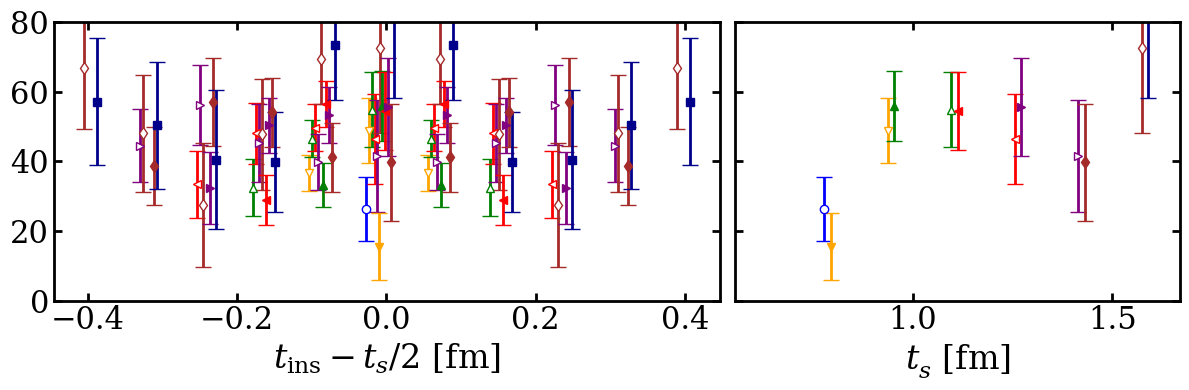

In [226]:
n1=2;n2=2
dic={'tf2ratio':dEdE2tf2ratio_GEVP(dE*0+364/yu.ens2aInv[ens],dE*0+1000/yu.ens2aInv[ens],n1=n1,n2=n2), 'rainbow:[tfmin,tfmax,tcmin,dt]': [None,None,1+n1+n2,None], 'mfc:[global]':['white'], 'shift:[rainbow,midpoint,fit]':[-0.2,-0.2,0], 'xyunit':(yu.ens2a[ens],yunit_mul) }
fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','midpoint'])
axs[0,0].set_ylim([0,80])
dic={'tf2ratio':filter(tf2ratio_GEVP,[364/yu.ens2aInv[ens],800/yu.ens2aInv[ens]],n1+n2,ridge=1), 'rainbow:[tfmin,tfmax,tcmin,dt]': [None,None,None,None], 'mfc:[global]':['None'], 'xyunit':(yu.ens2a[ens],yunit_mul) }
fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','midpoint'],figAxs=(fig,axs))
# fig.suptitle('open (R_GEVP); filled (R_GEVP_lap)')
yu.finalizePlot(closeQ=False)

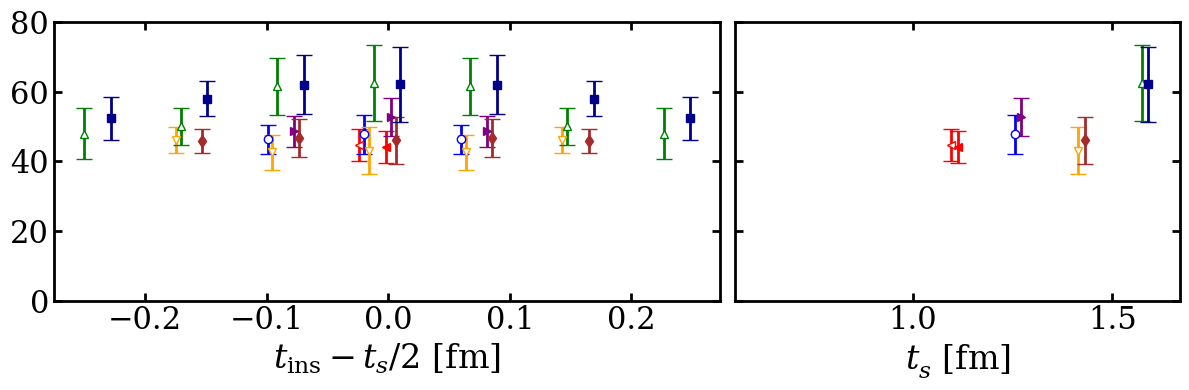

In [225]:
n1=3;n2=3
dic={'tf2ratio':dEdE2tf2ratio_GEVP(dE*0+364/yu.ens2aInv[ens],dE*0+1000/yu.ens2aInv[ens],n1=n1,n2=n2), 'rainbow:[tfmin,tfmax,tcmin,dt]': [None,None,1+n1+n2,None], 'mfc:[global]':['white'], 'shift:[rainbow,midpoint,fit]':[-0.2,-0.2,0], 'xyunit':(yu.ens2a[ens],yunit_mul) }
fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','midpoint'])
axs[0,0].set_ylim([0,80])
dic={'tf2ratio':filter(tf2ratio_GEVP,[364/yu.ens2aInv[ens],800/yu.ens2aInv[ens]],n1+n2,ridge=1), 'rainbow:[tfmin,tfmax,tcmin,dt]': [None,None,None,None], 'mfc:[global]':['None'], 'xyunit':(yu.ens2a[ens],yunit_mul) }
fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','midpoint'],figAxs=(fig,axs))
# fig.suptitle('open (R_GEVP); filled (R_GEVP_lap)')
yu.finalizePlot(closeQ=False)

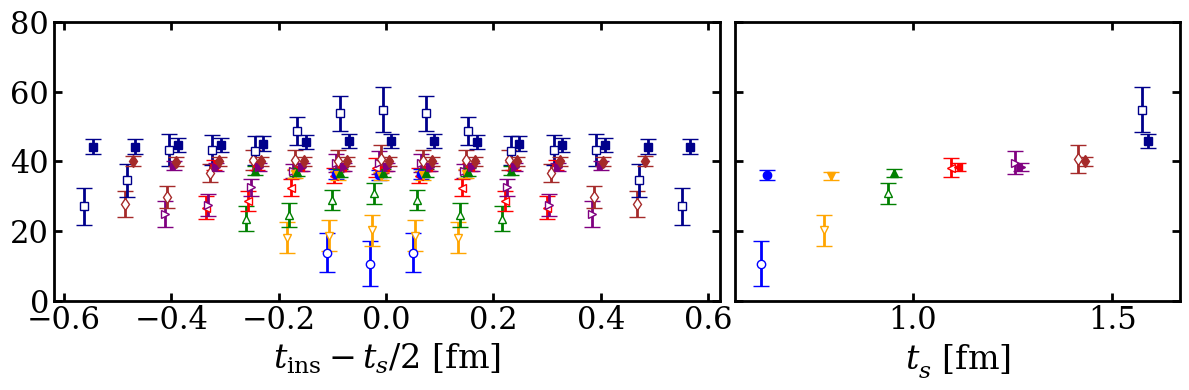

In [ ]:
tf2ratio1={}; tf2ratio2={}
for tf in tfs:
    c2=np.array([c2pt + v*(c2ptM[tf,0,1]+c2ptM[tf,1,0]) + v**2*c2ptM[tf,1,1]  for c3ptM,c2ptM,c2pt,v,w in zip(tf2c3ptM[tf],c2ptM,c2ptCorrDic_NJN[tf],v_selected,w_selected)])
    c3=np.array([c3ptM[:,0,0]*(1-w**2) + v*(1+w)*(c3ptM[:,0,1]+c3ptM[:,1,0])  for c3ptM,c2ptM,c2pt,v,w in zip(tf2c3ptM[tf],c2ptM,c2ptCorrDic_NJN[tf],v_selected,w_selected)])
    
    r_noGEVP=np.array([c3ptM[:,0,0]/c2pt for c3ptM,c2ptM,c2pt,v,w in zip(tf2c3ptM[tf],c2ptM,c2ptCorrDic_NJN[tf],v_selected,w_selected)])
    r=c3/c2[:,None]
    
    
    
    tf2ratio1[tf]=r_noGEVP
    tf2ratio2[tf]=r


dic={'tf2ratio':dE2tf2ratio_GEVP(dE), 'rainbow:[tfmin,tfmax,tcmin,dt]': [None,None,3,None], 'mfc:[global]':['white'], 'shift:[rainbow,midpoint,fit]':[-0.2,-0.2,0], 'xyunit':(yu.ens2a[ens],yunit_mul) }
fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','midpoint'])
axs[0,0].set_ylim([0,80])
dic={'tf2ratio':tf2ratio2, 'rainbow:[tfmin,tfmax,tcmin,dt]': [None,None,3,None], 'mfc:[global]':['None'], 'xyunit':(yu.ens2a[ens],yunit_mul) }
fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','midpoint'],figAxs=(fig,axs))
# fig.suptitle('open (R_GEVP); filled (R_GEVP_lap)')
yu.finalizePlot(closeQ=False)